# Dating app match prediction

## Data Preprocession

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("✅ Libraries imported!")

✅ Libraries imported!


# Loading and Inspecting data

In [2]:
df = pd.read_csv('../data/dating_dataset.csv')

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Shape: (50000, 19)
Rows: 50,000  |  Columns: 19


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [3]:
# check data types
print("Data Types:")
print(df.dtypes)
print()
# check missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Data Types:
gender                      str
sexual_orientation          str
location_type               str
income_bracket              str
education_level             str
interest_tags               str
app_usage_time_min        int64
app_usage_time_label        str
swipe_right_ratio       float64
swipe_right_label           str
likes_received            int64
mutual_matches            int64
profile_pics_count        int64
bio_length                int64
message_sent_count        int64
emoji_usage_rate        float64
last_active_hour          int64
swipe_time_of_day           str
match_outcome               str
dtype: object

Missing Values:
gender                  0
sexual_orientation      0
location_type           0
income_bracket          0
education_level         0
interest_tags           0
app_usage_time_min      0
app_usage_time_label    0
swipe_right_ratio       0
swipe_right_label       0
likes_received          0
mutual_matches          0
profile_pics_count      0
bio_length 

In [4]:
df.describe()

,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000
mean,149.912400,0.500655,99.526040,13.870280,2.98772,250.174400,50.07194,0.286205,11.521800
std,86.990521,0.197468,57.996799,9.105615,1.99678,144.800996,29.16800,0.160042,6.920474
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,0.000000
25%,74.000000,0.370000,49.000000,6.000000,1.00000,125.000000,25.00000,0.160000,5.000000
50%,150.000000,0.500000,100.000000,13.000000,3.00000,250.000000,50.00000,0.270000,12.000000
75%,225.000000,0.640000,150.000000,22.000000,5.00000,376.000000,75.00000,0.390000,18.000000
max,300.000000,1.000000,200.000000,30.000000,6.00000,500.000000,100.00000,0.940000,23.000000


# Exploratory Data Analysis

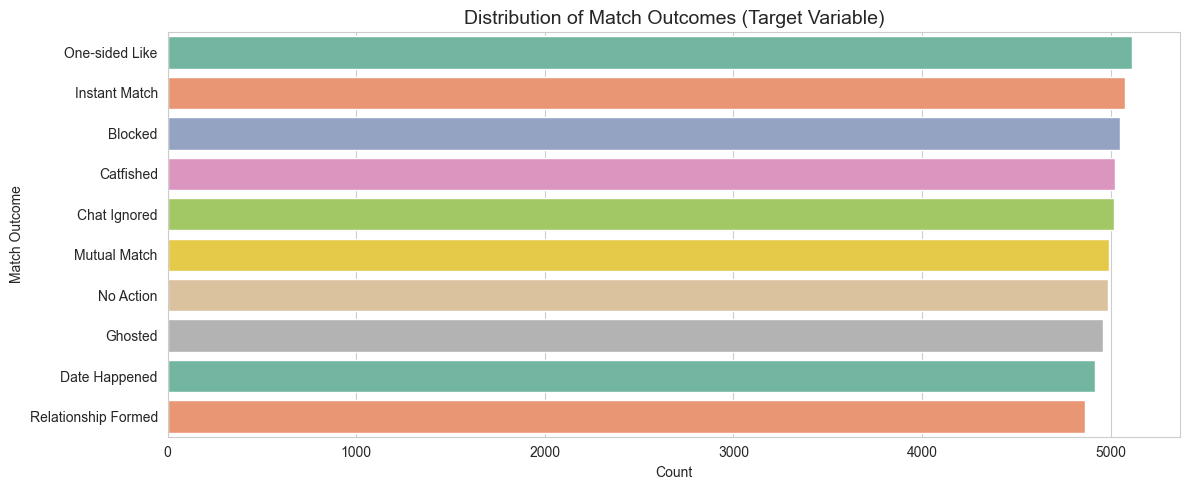

match_outcome
One-sided Like         5112
Instant Match          5078
Blocked                5049
Catfished              5025
Chat Ignored           5019
Mutual Match           4990
No Action              4986
Ghosted                4959
Date Happened          4919
Relationship Formed    4863
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(12, 5))
order = df['match_outcome'].value_counts().index
sns.countplot(data=df, y='match_outcome', order=order, palette='Set2')
plt.title('Distribution of Match Outcomes (Target Variable)', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Match Outcome')
plt.tight_layout()
plt.show()

print(df['match_outcome'].value_counts())

In [6]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('match_outcome')

for col in cat_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts().head(4))


gender — 6 unique values
gender
Female               8384
Non-binary           8366
Transgender          8353
Prefer Not to Say    8335
Name: count, dtype: int64

sexual_orientation — 8 unique values
sexual_orientation
Straight      6326
Lesbian       6315
Demisexual    6301
Queer         6288
Name: count, dtype: int64

location_type — 6 unique values
location_type
Remote Area    8519
Small Town     8343
Rural          8331
Suburban       8296
Name: count, dtype: int64

income_bracket — 7 unique values
income_bracket
High         7309
Very High    7178
Low          7132
Middle       7126
Name: count, dtype: int64

education_level — 9 unique values
education_level
Bachelor’s     5646
MBA            5637
High School    5632
PhD            5594
Name: count, dtype: int64

interest_tags — 40206 unique values
interest_tags
Fitness, Anime, Yoga                  6
Clubbing, Photography, Skating        5
Social Activism, Poetry, Clubbing     5
Skating, Binge-Watching, Investing    5
Name: coun

# Plots

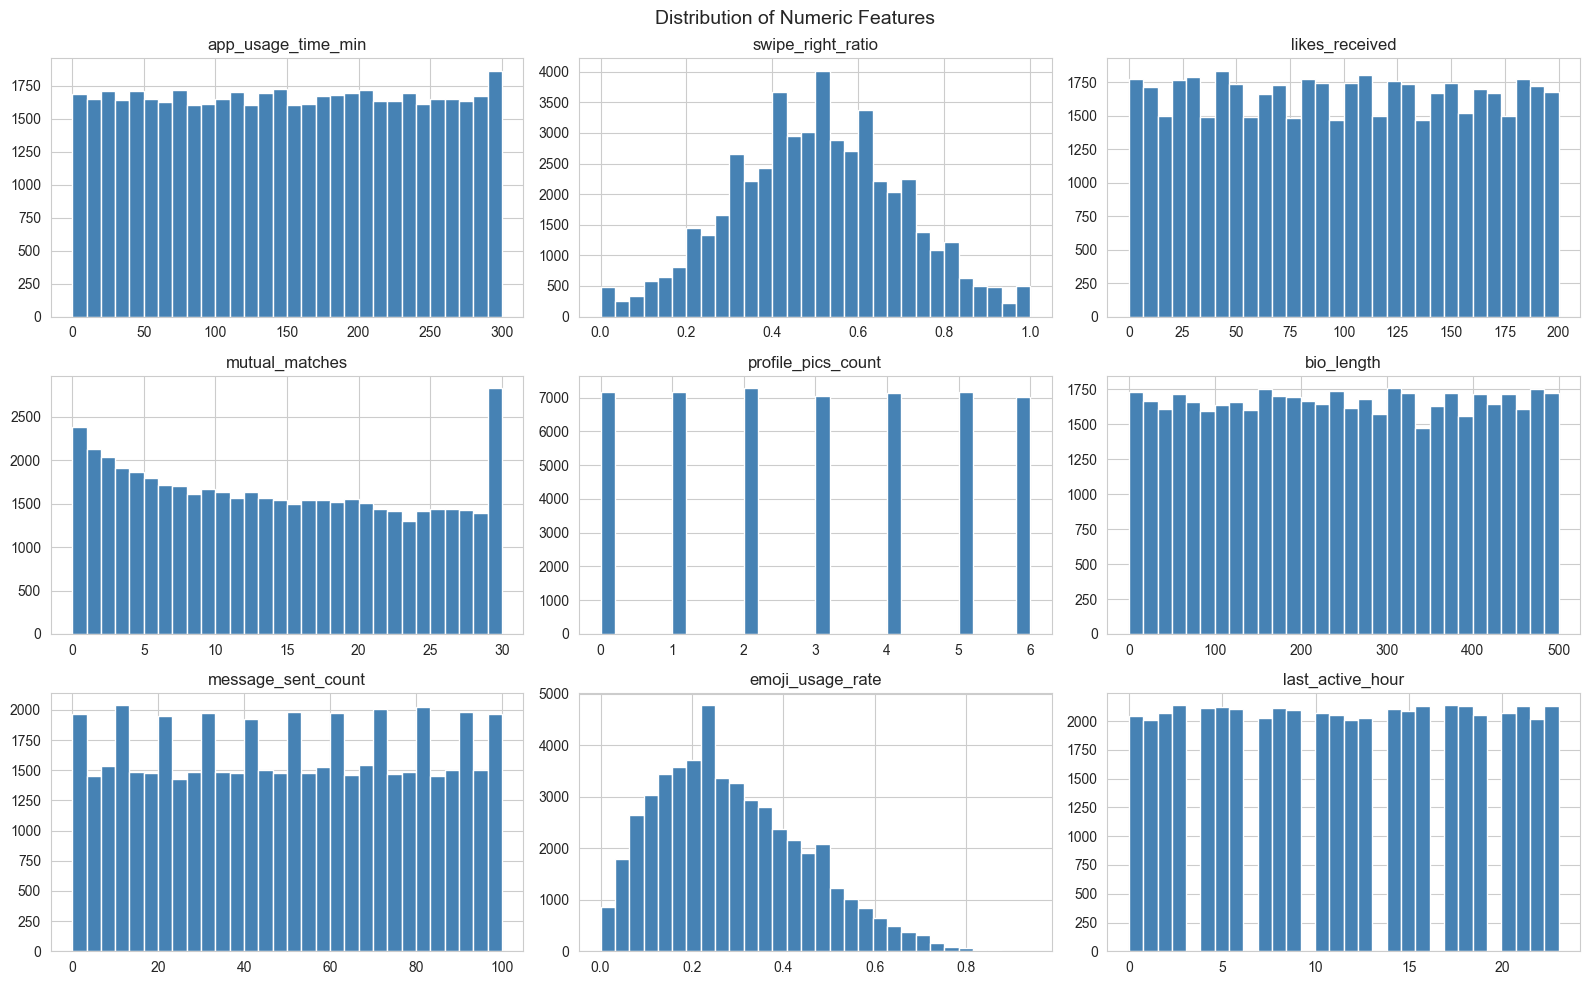

In [7]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df[num_cols].hist(bins=30, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation

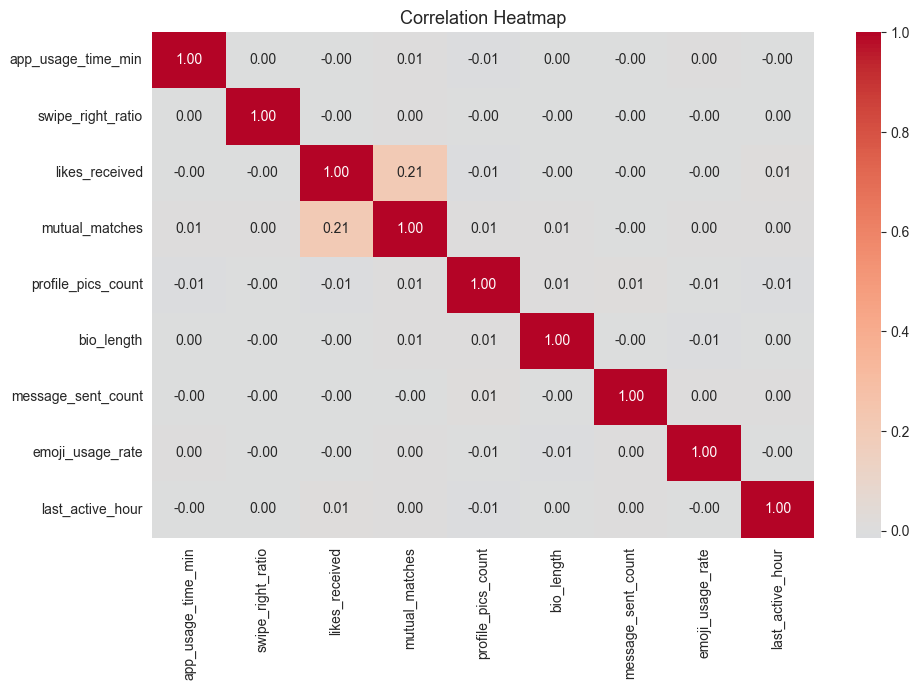

In [8]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

if dupes > 0:
    df = df.drop_duplicates()
    print(f"Removed! New shape: {df.shape}")
else:
    print("No duplicates — dataset is clean!")

Duplicate rows: 0
No duplicates — dataset is clean!


# Feature Engineering


In [10]:
# ── Ordinal Encoding for usage / swipe label columns ────────
usage_order = [['Very Low', 'Barely', 'Low', 'Moderate', 'High', 'Addicted', 'Extreme User']]
swipe_order = [['Choosy', 'Balanced', 'Optimistic', 'Swipe Maniac']]
df['usage_ordinal'] = OrdinalEncoder(categories=usage_order).fit_transform(df[['app_usage_time_label']])
df['swipe_ordinal']  = OrdinalEncoder(categories=swipe_order).fit_transform(df[['swipe_right_label']])

# ── Interest Tag One-Hot Encoding (49 individual tags) ────────
all_tags = sorted(set(t.strip() for row in df['interest_tags'] for t in row.split(',')))
for tag in all_tags:
    df[f'tag_{tag}'] = df['interest_tags'].apply(lambda x, t=tag: 1 if t in x else 0)

# ── Basic Features ───────────────────────────────────────────
df['interest_count'] = df['interest_tags'].apply(lambda x: len(str(x).split(',')))

df['profile_completeness'] = (
    (df['bio_length'] / df['bio_length'].max()) * 0.5 +
    (df['profile_pics_count'] / df['profile_pics_count'].max()) * 0.5
)

df['engagement_rate'] = df['mutual_matches'] / (df['likes_received'] + 1)

df['is_night_user'] = df['last_active_hour'].apply(
    lambda x: 1 if (x >= 22 or x <= 4) else 0
)

# ── Ratio & Interaction Features ─────────────────────────────
df['activity_score']   = df['app_usage_time_min'] * df['swipe_right_ratio']
df['social_score']     = df['message_sent_count'] * df['emoji_usage_rate']
df['msg_per_match']    = df['message_sent_count'] / (df['mutual_matches'] + 1)
df['like_efficiency']  = df['mutual_matches'] / (df['likes_received'] + 1)
df['profile_appeal']   = df['likes_received'] / (df['profile_pics_count'] + 1)
df['bio_per_pic']      = df['bio_length'] / (df['profile_pics_count'] + 1)
df['match_ratio']      = df['mutual_matches'] / (df['app_usage_time_min'] + 1)
df['comm_effort']      = df['message_sent_count'] * df['app_usage_time_min']

# ── Cyclical Time Encoding ────────────────────────────────────
df['hour_sin'] = np.sin(2 * np.pi * df['last_active_hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['last_active_hour'] / 24)

# ── Log Transforms (reduce skew) ─────────────────────────────
df['log_likes']   = np.log1p(df['likes_received'])
df['log_msgs']    = np.log1p(df['message_sent_count'])
df['log_matches'] = np.log1p(df['mutual_matches'])

# ── Polynomial Features ───────────────────────────────────────
df['sq_swipe']      = df['swipe_right_ratio'] ** 2
df['sq_engagement'] = df['engagement_rate'] ** 2
df['sq_social']     = df['social_score'] ** 2

total_new = 2 + len(all_tags) + 23  # ordinal + tags + engineered
print(f"✅ {total_new} new features created ({len(all_tags)} interest tag flags + 25 engineered)!")
new_feat_cols = ['usage_ordinal','swipe_ordinal','interest_count','profile_completeness',
                 'engagement_rate','is_night_user','activity_score','social_score',
                 'msg_per_match','like_efficiency','profile_appeal','bio_per_pic',
                 'match_ratio','comm_effort','hour_sin','hour_cos',
                 'log_likes','log_msgs','log_matches','sq_swipe','sq_engagement','sq_social']
print(df[new_feat_cols].head(3))

✅ 74 new features created (49 interest tag flags + 25 engineered)!
   usage_ordinal  swipe_ordinal  interest_count  profile_completeness  \
0            3.0            2.0               3              0.377333   
1            6.0            2.0               3              0.551000   
2            3.0            2.0               3              0.475667   

   engagement_rate  is_night_user  activity_score  social_score  \
0         0.132184              0           31.20         27.00   
1         0.064815              1          156.24         14.70   
2         0.293478              1           20.09         13.53   

   msg_per_match  like_efficiency  profile_appeal  bio_per_pic  match_ratio  \
0       3.125000         0.132184       34.600000         8.80     0.433962   
1       4.375000         0.064815       26.750000        75.25     0.025000   
2       1.178571         0.293478       30.333333       103.00     0.540000   

   comm_effort  hour_sin  hour_cos  log_likes  log_msg

In [11]:
cols_to_drop = ['interest_tags', 'app_usage_time_label', 'swipe_right_label']
df = df.drop(columns=cols_to_drop)

print(f"Dropped: {cols_to_drop}")
print(f"New shape: {df.shape}")

Dropped: ['interest_tags', 'app_usage_time_label', 'swipe_right_label']
New shape: (50000, 87)


In [12]:
le = LabelEncoder()
df['match_outcome_encoded'] = le.fit_transform(df['match_outcome'])

label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Target Encoding Map:")
for k, v in label_mapping.items():
    print(f"  {k} → {v}")

Target Encoding Map:
  Blocked → 0
  Catfished → 1
  Chat Ignored → 2
  Date Happened → 3
  Ghosted → 4
  Instant Match → 5
  Mutual Match → 6
  No Action → 7
  One-sided Like → 8
  Relationship Formed → 9


In [13]:
nominal_cols = ['gender', 'sexual_orientation', 'location_type',
                'income_bracket', 'education_level', 'swipe_time_of_day']

df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

# Drop original string target column
df = df.drop(columns=['match_outcome'])

print(f"Shape after encoding: {df.shape}")

Shape after encoding: (50000, 117)


# Feature Scaling

In [14]:
X = df.drop(columns=['match_outcome_encoded'])
y = df['match_outcome_encoded']

# Scale continuous / ordinal features (tag dummies are already 0/1)
num_features = [
    'app_usage_time_min', 'swipe_right_ratio', 'likes_received',
    'mutual_matches', 'profile_pics_count', 'bio_length',
    'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
    'usage_ordinal', 'swipe_ordinal',
    'interest_count', 'profile_completeness', 'engagement_rate',
    'activity_score', 'social_score', 'msg_per_match', 'like_efficiency',
    'profile_appeal', 'bio_per_pic', 'match_ratio', 'comm_effort',
    'log_likes', 'log_msgs', 'log_matches', 'sq_swipe', 'sq_engagement', 'sq_social'
]

scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# Save splits for Task 2
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

import os
os.makedirs('../models', exist_ok=True)

with open('../models/scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('../models/label_encoder.pkl', 'wb') as f: pickle.dump(le, f)
with open('../models/label_mapping.pkl', 'wb') as f: pickle.dump(label_mapping, f)

feature_columns = list(X.columns)
with open('../models/feature_columns.pkl', 'wb') as f: pickle.dump(feature_columns, f)

print("✅ All files saved!")
print(f"   Features saved: {len(feature_columns)}")

Train: (40000, 116)  |  Test: (10000, 116)


✅ All files saved!
   Features saved: 116


# Model Training and Evaluation

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Load preprocessed data from Task 1
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

with open('../models/label_mapping.pkl', 'rb') as f:
    label_mapping = pickle.load(f)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Classes: {y_train.nunique()}")
print("\n✅ Data loaded successfully!")

Train: (40000, 116) | Test: (10000, 116)
Classes: 10

✅ Data loaded successfully!


In [16]:
print("=" * 60)
print("ADDITIONAL INTERACTION FEATURES (Task 2)")
print("=" * 60)

X_train_enhanced = X_train.copy()
X_test_enhanced  = X_test.copy()

# Cross-feature interactions on scaled data
for Xe, Xs in [(X_train_enhanced, X_train), (X_test_enhanced, X_test)]:
    Xe['likes_x_swipe']   = Xs['likes_received']      * Xs['swipe_right_ratio']
    Xe['profile_x_bio']   = Xs['profile_pics_count']  * Xs['bio_length']
    Xe['app_x_msg']       = Xs['app_usage_time_min']  * Xs['message_sent_count']
    Xe['emoji_x_msg']     = Xs['emoji_usage_rate']    * Xs['message_sent_count']
    Xe['engage_x_social'] = Xs['engagement_rate']     * Xs['social_score']
    Xe['like_x_profile']  = Xs['like_efficiency']     * Xs['profile_completeness']

# Clean up any inf / NaN introduced by interactions
for df_ in [X_train_enhanced, X_test_enhanced]:
    df_.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_.fillna(0, inplace=True)

print(f"  Original shape : {X_train.shape}")
print(f"  Enhanced shape : {X_train_enhanced.shape}")
print(f"  New features   : {X_train_enhanced.shape[1] - X_train.shape[1]}")
print("\n✅ Feature engineering complete!")

ADDITIONAL INTERACTION FEATURES (Task 2)
  Original shape : (40000, 116)
  Enhanced shape : (40000, 122)
  New features   : 6

✅ Feature engineering complete!


In [17]:
print("=" * 60)
print("TRAINING MODELS")
print("=" * 60)

# ── 1. XGBoost ────────────────────────────────────────────────
print("\n1️⃣  Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    reg_alpha=0.5,
    reg_lambda=2.0,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train_enhanced, y_train)
xgb_preds    = xgb_model.predict(X_test_enhanced)
xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_f1       = f1_score(y_test, xgb_preds, average='weighted')
print(f"   ✅ Accuracy: {xgb_accuracy*100:.2f}% | F1: {xgb_f1:.4f}")

# ── 2. LightGBM ───────────────────────────────────────────────
print("\n2️⃣  Training LightGBM...")
lgb_model = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
lgb_model.fit(X_train_enhanced, y_train)
lgb_preds    = lgb_model.predict(X_test_enhanced)
lgb_accuracy = accuracy_score(y_test, lgb_preds)
lgb_f1       = f1_score(y_test, lgb_preds, average='weighted')
print(f"   ✅ Accuracy: {lgb_accuracy*100:.2f}% | F1: {lgb_f1:.4f}")

# ── 3. CatBoost ───────────────────────────────────────────────
print("\n3️⃣  Training CatBoost...")
cb_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=5,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_seed=42,
    verbose=0
)
cb_model.fit(X_train_enhanced, y_train)
cb_preds    = cb_model.predict(X_test_enhanced).flatten()
cb_accuracy = accuracy_score(y_test, cb_preds)
cb_f1       = f1_score(y_test, cb_preds, average='weighted')
print(f"   ✅ Accuracy: {cb_accuracy*100:.2f}% | F1: {cb_f1:.4f}")

# ── 4. Random Forest ──────────────────────────────────────────
print("\n4️⃣  Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_enhanced, y_train)
rf_preds    = rf_model.predict(X_test_enhanced)
rf_accuracy = accuracy_score(y_test, rf_preds)
rf_f1       = f1_score(y_test, rf_preds, average='weighted')
print(f"   ✅ Accuracy: {rf_accuracy*100:.2f}% | F1: {rf_f1:.4f}")

# ── 5. Neural Network (MLP) ───────────────────────────────────
print("\n5️⃣  Training Neural Network (MLP)...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.1,
    random_state=42
)
mlp_model.fit(X_train_enhanced, y_train)
mlp_preds    = mlp_model.predict(X_test_enhanced)
mlp_accuracy = accuracy_score(y_test, mlp_preds)
mlp_f1       = f1_score(y_test, mlp_preds, average='weighted')
print(f"   ✅ Accuracy: {mlp_accuracy*100:.2f}% | F1: {mlp_f1:.4f}")

# ── 6. Stacking Ensemble ──────────────────────────────────────
print("\n6️⃣  Training Stacking Ensemble (XGB + LGB + MLP → LR)...")
stacking_model = StackingClassifier(
    estimators=[
        ('xgb', XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                              verbosity=0, random_state=42, n_jobs=-1)),
        ('lgb', LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                               verbose=-1, random_state=42, n_jobs=-1)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=200,
                              early_stopping=True, random_state=42)),
    ],
    final_estimator=LogisticRegression(C=0.1, max_iter=500, random_state=42),
    cv=3,
    n_jobs=-1
)
stacking_model.fit(X_train_enhanced, y_train)
stacking_preds    = stacking_model.predict(X_test_enhanced)
stacking_accuracy = accuracy_score(y_test, stacking_preds)
stacking_f1       = f1_score(y_test, stacking_preds, average='weighted')
print(f"   ✅ Accuracy: {stacking_accuracy*100:.2f}% | F1: {stacking_f1:.4f}")

print("\n" + "=" * 60)
print("✅ ALL MODELS TRAINED SUCCESSFULLY!")
print("=" * 60)

TRAINING MODELS

1️⃣  Training XGBoost...


   ✅ Accuracy: 9.84% | F1: 0.0984

2️⃣  Training LightGBM...


   ✅ Accuracy: 9.32% | F1: 0.0932

3️⃣  Training CatBoost...


   ✅ Accuracy: 9.86% | F1: 0.0972

4️⃣  Training Random Forest...


   ✅ Accuracy: 9.69% | F1: 0.0968

5️⃣  Training Neural Network (MLP)...


   ✅ Accuracy: 9.36% | F1: 0.0925

6️⃣  Training Stacking Ensemble (XGB + LGB + MLP → LR)...


   ✅ Accuracy: 10.44% | F1: 0.0738

✅ ALL MODELS TRAINED SUCCESSFULLY!


MODEL PERFORMANCE COMPARISON

            Model  Accuracy  F1-Score
Stacking Ensemble     10.44  0.073845
         CatBoost      9.86  0.097205
          XGBoost      9.84  0.098435
    Random Forest      9.69  0.096830
 MLP (Neural Net)      9.36  0.092502
         LightGBM      9.32  0.093178

🏆 Best Model : Stacking Ensemble
   Accuracy   : 10.44%


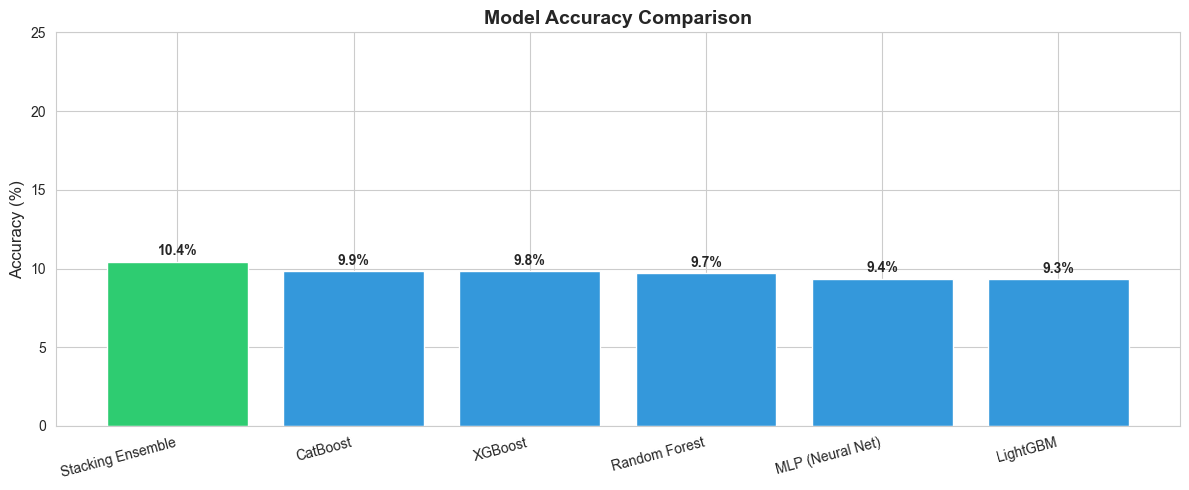

In [18]:
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)

results_df = pd.DataFrame({
    'Model':    ['XGBoost', 'LightGBM', 'CatBoost', 'Random Forest', 'MLP (Neural Net)', 'Stacking Ensemble'],
    'Accuracy': [xgb_accuracy*100, lgb_accuracy*100, cb_accuracy*100, rf_accuracy*100,
                 mlp_accuracy*100, stacking_accuracy*100],
    'F1-Score': [xgb_f1, lgb_f1, cb_f1, rf_f1, mlp_f1, stacking_f1]
})

results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print("\n" + results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
best_accuracy   = results_df.iloc[0]['Accuracy']
print(f"\n🏆 Best Model : {best_model_name}")
print(f"   Accuracy   : {best_accuracy:.2f}%")

# Bar chart
plt.figure(figsize=(12, 5))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(results_df))]
bars = plt.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='white')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 25)
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Select best predictions for downstream cells
model_map = {
    'XGBoost':           (xgb_preds,      xgb_model),
    'LightGBM':          (lgb_preds,      lgb_model),
    'CatBoost':          (cb_preds,       cb_model),
    'Random Forest':     (rf_preds,       rf_model),
    'MLP (Neural Net)':  (mlp_preds,      mlp_model),
    'Stacking Ensemble': (stacking_preds, stacking_model),
}
best_preds, best_model = model_map[best_model_name]


DETAILED CLASSIFICATION REPORT: Stacking Ensemble
                     precision    recall  f1-score   support

            Blocked       0.11      0.10      0.10      1010
          Catfished       0.11      0.11      0.11      1005
       Chat Ignored       0.10      0.12      0.11      1004
      Date Happened       0.13      0.01      0.01       984
            Ghosted       0.00      0.00      0.00       992
      Instant Match       0.10      0.24      0.15      1016
       Mutual Match       0.08      0.01      0.02       998
          No Action       0.12      0.04      0.06       997
     One-sided Like       0.10      0.40      0.16      1022
Relationship Formed       0.07      0.00      0.00       972

           accuracy                           0.10     10000
          macro avg       0.09      0.10      0.07     10000
       weighted avg       0.09      0.10      0.07     10000


CONFUSION MATRIX


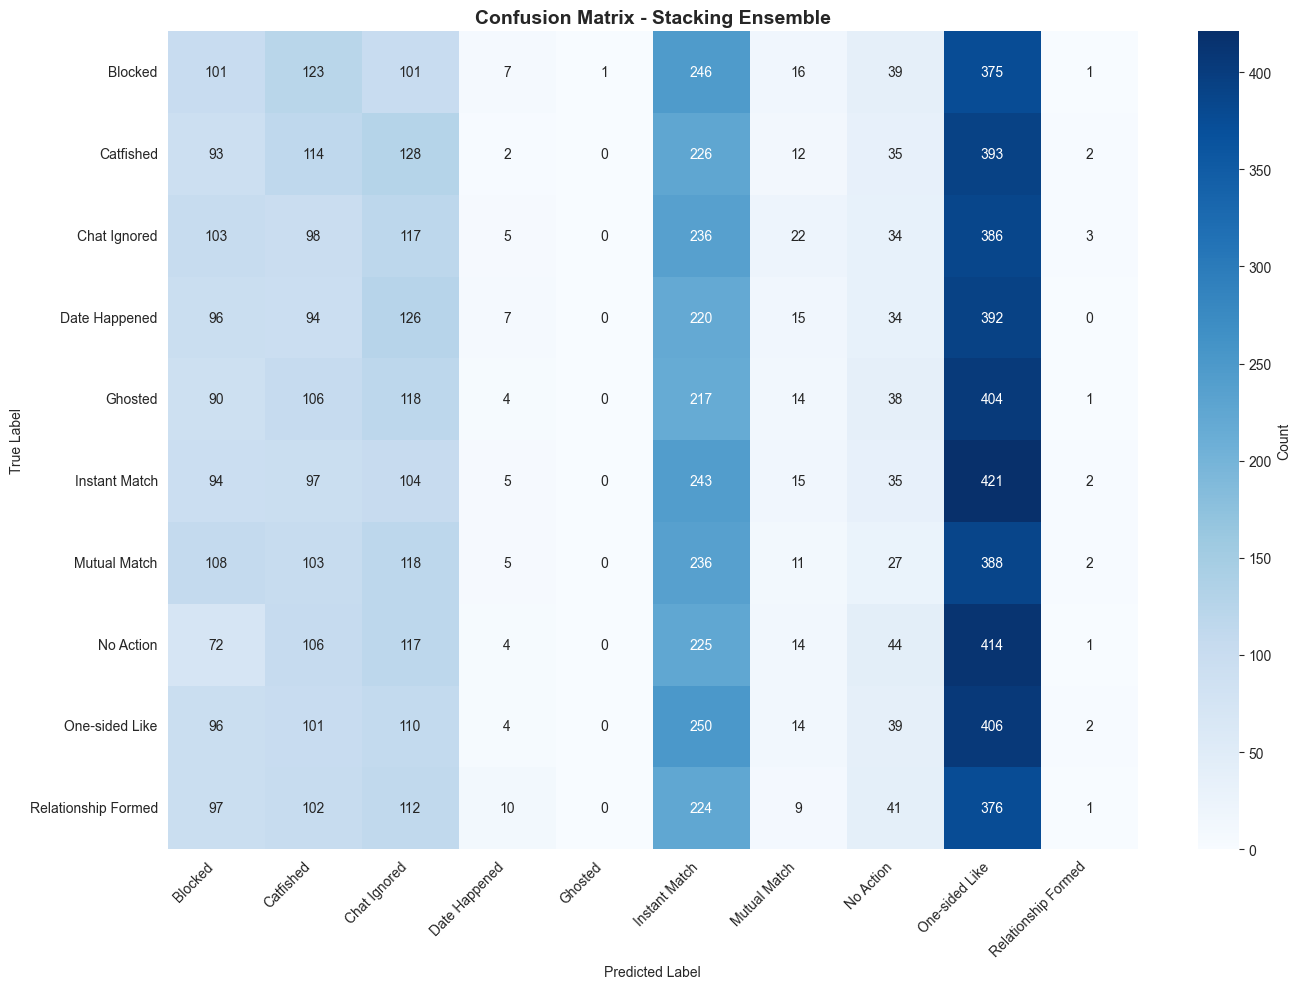


✅ Confusion matrix plotted!


In [19]:
print("\n" + "=" * 60)
print(f"DETAILED CLASSIFICATION REPORT: {best_model_name}")
print("=" * 60)
print(classification_report(y_test, best_preds, 
                          target_names=list(label_mapping.keys())))

# Confusion Matrix
print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
cm = confusion_matrix(y_test, best_preds)

# Create heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=list(label_mapping.keys()),
            yticklabels=list(label_mapping.keys()),
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\n✅ Confusion matrix plotted!")

In [20]:
print("=" * 60)
print("3-FOLD STRATIFIED CROSS-VALIDATION")
print("=" * 60)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for model_name, model in [('XGBoost', xgb_model),
                           ('LightGBM', lgb_model),
                           ('Random Forest', rf_model)]:
    scores = cross_val_score(model, X_train_enhanced, y_train,
                             cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"\n{model_name}:")
    print(f"  Fold Scores  : {[f'{s:.4f}' for s in scores]}")
    print(f"  Mean Accuracy: {scores.mean()*100:.2f}% (±{scores.std()*100:.2f}%)")

print("\n✅ Cross-validation complete!")

3-FOLD STRATIFIED CROSS-VALIDATION



XGBoost:
  Fold Scores  : ['0.1024', '0.1031', '0.1039']
  Mean Accuracy: 10.32% (±0.06%)



LightGBM:
  Fold Scores  : ['0.1046', '0.0989', '0.1025']
  Mean Accuracy: 10.20% (±0.24%)



Random Forest:
  Fold Scores  : ['0.1024', '0.0958', '0.1010']
  Mean Accuracy: 9.97% (±0.28%)

✅ Cross-validation complete!


FEATURE IMPORTANCE — XGBoost

Top 20 Most Important Features:
                Feature  Importance
               tag_Yoga    0.008863
            tag_Running    0.008775
             tag_Foodie    0.008726
          is_night_user    0.008682
           tag_Startups    0.008670
       tag_Spirituality    0.008668
          tag_Investing    0.008608
             tag_Coding    0.008607
              tag_Memes    0.008599
             tag_Hiking    0.008594
            tag_Skating    0.008594
                tag_DIY    0.008585
     tag_Binge-Watching    0.008568
           tag_Crafting    0.008558
            tag_Writing    0.008548
            tag_Cooking    0.008544
education_level_Diploma    0.008520
               tag_Cars    0.008496
       tag_Motorcycling    0.008487
             tag_Poetry    0.008473


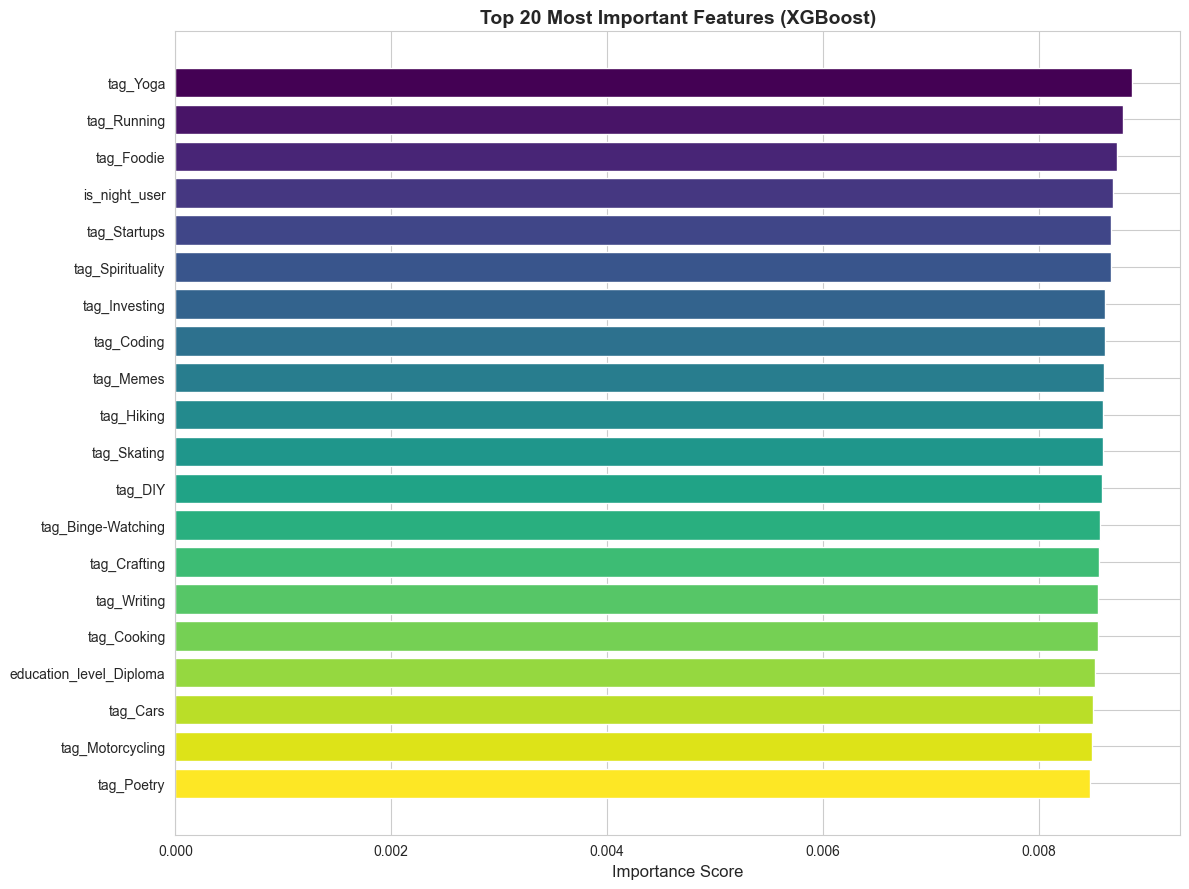


✅ Feature importance analysis complete!


In [21]:
print("=" * 60)
print("FEATURE IMPORTANCE — XGBoost")
print("=" * 60)

feat_imp = pd.DataFrame({
    'Feature':    X_train_enhanced.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(12, 9))
top20 = feat_imp.head(20)
colors = plt.cm.viridis(np.linspace(0, 1, len(top20)))
plt.barh(range(len(top20)), top20['Importance'], color=colors)
plt.yticks(range(len(top20)), top20['Feature'], fontsize=10)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✅ Feature importance analysis complete!")

In [22]:
print("=" * 60)
print("SAVING MODELS")
print("=" * 60)

import os
os.makedirs('../models', exist_ok=True)

with open('../models/xgb_model_improved.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)
print("✅ Saved: xgb_model_improved.pkl")

with open('../models/lgb_model_improved.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
print("✅ Saved: lgb_model_improved.pkl")

with open('../models/rf_model_improved.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("✅ Saved: rf_model_improved.pkl")

cb_model.save_model('../models/cb_model_improved.cbm')
print("✅ Saved: cb_model_improved.cbm")

with open('../models/mlp_model_improved.pkl', 'wb') as f:
    pickle.dump(mlp_model, f)
print("✅ Saved: mlp_model_improved.pkl")

with open('../models/stacking_model.pkl', 'wb') as f:
    pickle.dump(stacking_model, f)
print("✅ Saved: stacking_model.pkl")

with open('../models/feature_columns_enhanced.pkl', 'wb') as f:
    pickle.dump(list(X_train_enhanced.columns), f)
print("✅ Saved: feature_columns_enhanced.pkl")

results_summary = {
    'best_model': best_model_name,
    'best_accuracy': best_accuracy,
    'all_results': results_df.to_dict('records')
}
with open('../models/model_results_summary.pkl', 'wb') as f:
    pickle.dump(results_summary, f)
print("✅ Saved: model_results_summary.pkl")

print("\n🎉 All models saved successfully!")

SAVING MODELS


✅ Saved: xgb_model_improved.pkl


✅ Saved: lgb_model_improved.pkl
✅ Saved: rf_model_improved.pkl
✅ Saved: cb_model_improved.cbm
✅ Saved: mlp_model_improved.pkl


✅ Saved: stacking_model.pkl
✅ Saved: feature_columns_enhanced.pkl
✅ Saved: model_results_summary.pkl

🎉 All models saved successfully!


# Test on Sample Profiles

In [23]:
import pickle
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from dotenv import load_dotenv
import os

load_dotenv()
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# Load models
with open('../models/xgb_model_improved.pkl', 'rb') as f:
    xgb_model_loaded = pickle.load(f)

with open('../models/lgb_model_improved.pkl', 'rb') as f:
    lgb_model_loaded = pickle.load(f)

with open('../models/rf_model_improved.pkl', 'rb') as f:
    rf_model_loaded = pickle.load(f)

cb_model_loaded = CatBoostClassifier()
cb_model_loaded.load_model('../models/cb_model_improved.cbm')

with open('../models/mlp_model_improved.pkl', 'rb') as f:
    mlp_model_loaded = pickle.load(f)

with open('../models/stacking_model.pkl', 'rb') as f:
    stacking_model_loaded = pickle.load(f)

# Load preprocessing artifacts
with open('../models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

with open('../models/label_mapping.pkl', 'rb') as f:
    label_mapping = pickle.load(f)

with open('../models/feature_columns_enhanced.pkl', 'rb') as f:
    feature_columns_enhanced = pickle.load(f)

try:
    with open('../models/model_results_summary.pkl', 'rb') as f:
        results_summary = pickle.load(f)
    best_model_name = results_summary['best_model']
    best_accuracy   = results_summary['best_accuracy']
except:
    best_model_name = 'Stacking Ensemble'
    best_accuracy   = 0.0

reverse_mapping = {v: k for k, v in label_mapping.items()}

# Tag list used during training — must match Cell 16
_raw = pd.read_csv('../data/dating_dataset.csv')
ALL_TAGS = sorted(set(t.strip() for row in _raw['interest_tags'] for t in row.split(',')))

default_model = stacking_model_loaded

print("✅ All models loaded!")
print(f"Best Model : {best_model_name}  ({best_accuracy:.2f}%)")
print(f"Classes    : {list(label_mapping.keys())}")

✅ All models loaded!
Best Model : Stacking Ensemble  (10.44%)
Classes    : ['Blocked', 'Catfished', 'Chat Ignored', 'Date Happened', 'Ghosted', 'Instant Match', 'Mutual Match', 'No Action', 'One-sided Like', 'Relationship Formed']


In [24]:

profile_1 = {
    "gender": "Male",
    "sexual_orientation": "Straight",
    "location_type": "Urban",
    "income_bracket": "Middle",
    "education_level": "Bachelor's",
    "interest_tags": "Fitness, Movies, Traveling",
    "app_usage_time_min": 120,
    "swipe_right_ratio": 0.65,
    "likes_received": 85,
    "mutual_matches": 12,
    "profile_pics_count": 4,
    "bio_length": 180,
    "message_sent_count": 45,
    "emoji_usage_rate": 0.3,
    "last_active_hour": 21,
    "swipe_time_of_day": "Evening"
}

profile_2 = {
    "gender": "Female",
    "sexual_orientation": "Straight",
    "location_type": "Urban",
    "income_bracket": "Middle",
    "education_level": "Master's",
    "interest_tags": "Fitness, Cooking, Traveling",
    "app_usage_time_min": 95,
    "swipe_right_ratio": 0.45,
    "likes_received": 120,
    "mutual_matches": 18,
    "profile_pics_count": 5,
    "bio_length": 220,
    "message_sent_count": 60,
    "emoji_usage_rate": 0.4,
    "last_active_hour": 20,
    "swipe_time_of_day": "Evening"
}

print("✅ Profiles defined!")
print(f"\nProfile 1: {profile_1['gender']}, {profile_1['location_type']}, {profile_1['education_level']}")
print(f"Profile 2: {profile_2['gender']}, {profile_2['location_type']}, {profile_2['education_level']}")

✅ Profiles defined!

Profile 1: Male, Urban, Bachelor's
Profile 2: Female, Urban, Master's


In [25]:
def preprocess_profile_enhanced(profile):
    """Mirror the full Task-1 + Task-2 feature pipeline for a single profile dict."""
    df = pd.DataFrame([profile])

    # ── Ordinal: derive from numeric cols (no string label needed) ──
    usage_bins   = [0, 5, 15, 30, 60, 120, 180, 301]
    usage_labels = [0, 1, 2, 3, 4, 5, 6]
    df['usage_ordinal'] = pd.cut(
        df['app_usage_time_min'], bins=usage_bins,
        labels=usage_labels, right=False, include_lowest=True
    ).astype(float)

    swipe_bins   = [0, 0.2, 0.4, 0.7, 1.01]
    swipe_labels = [0, 1, 2, 3]
    df['swipe_ordinal'] = pd.cut(
        df['swipe_right_ratio'], bins=swipe_bins,
        labels=swipe_labels, right=False, include_lowest=True
    ).astype(float)

    # ── Interest tag OHE (49 tags) ───────────────────────────
    for tag in ALL_TAGS:
        df[f'tag_{tag}'] = 1 if tag in str(profile.get('interest_tags', '')) else 0

    # ── Engineered features ───────────────────────────────────
    df['interest_count']       = len(str(profile.get('interest_tags', '')).split(','))
    df['profile_completeness'] = (df['bio_length'] / 500) * 0.5 + (df['profile_pics_count'] / 6) * 0.5
    df['engagement_rate']      = df['mutual_matches'] / (df['likes_received'] + 1)
    df['is_night_user']        = int(profile['last_active_hour'] >= 22 or profile['last_active_hour'] <= 4)
    df['activity_score']       = df['app_usage_time_min'] * df['swipe_right_ratio']
    df['social_score']         = df['message_sent_count'] * df['emoji_usage_rate']
    df['msg_per_match']        = df['message_sent_count'] / (df['mutual_matches'] + 1)
    df['like_efficiency']      = df['mutual_matches'] / (df['likes_received'] + 1)
    df['profile_appeal']       = df['likes_received'] / (df['profile_pics_count'] + 1)
    df['bio_per_pic']          = df['bio_length'] / (df['profile_pics_count'] + 1)
    df['match_ratio']          = df['mutual_matches'] / (df['app_usage_time_min'] + 1)
    df['comm_effort']          = df['message_sent_count'] * df['app_usage_time_min']
    df['hour_sin']             = np.sin(2 * np.pi * df['last_active_hour'] / 24)
    df['hour_cos']             = np.cos(2 * np.pi * df['last_active_hour'] / 24)
    df['log_likes']            = np.log1p(df['likes_received'])
    df['log_msgs']             = np.log1p(df['message_sent_count'])
    df['log_matches']          = np.log1p(df['mutual_matches'])
    df['sq_swipe']             = df['swipe_right_ratio'] ** 2
    df['sq_engagement']        = df['engagement_rate'] ** 2
    df['sq_social']            = df['social_score'] ** 2

    # ── Drop original label / tag columns if present ──────────
    df.drop(columns=['interest_tags', 'app_usage_time_label', 'swipe_right_label'],
            errors='ignore', inplace=True)

    # ── One-Hot Encode categoricals ───────────────────────────
    nominal_cols = ['gender', 'sexual_orientation', 'location_type',
                    'income_bracket', 'education_level', 'swipe_time_of_day']
    df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

    # ── Scale numeric features ────────────────────────────────
    num_features = [
        'app_usage_time_min', 'swipe_right_ratio', 'likes_received',
        'mutual_matches', 'profile_pics_count', 'bio_length',
        'message_sent_count', 'emoji_usage_rate', 'last_active_hour',
        'usage_ordinal', 'swipe_ordinal',
        'interest_count', 'profile_completeness', 'engagement_rate',
        'activity_score', 'social_score', 'msg_per_match', 'like_efficiency',
        'profile_appeal', 'bio_per_pic', 'match_ratio', 'comm_effort',
        'log_likes', 'log_msgs', 'log_matches', 'sq_swipe', 'sq_engagement', 'sq_social'
    ]
    cols_to_scale = [c for c in num_features if c in df.columns]
    df[cols_to_scale] = scaler.transform(df[cols_to_scale])

    # ── Task-2 interaction features ───────────────────────────
    for col_a, col_b, name in [
        ('likes_received',     'swipe_right_ratio',    'likes_x_swipe'),
        ('profile_pics_count', 'bio_length',           'profile_x_bio'),
        ('app_usage_time_min', 'message_sent_count',   'app_x_msg'),
        ('emoji_usage_rate',   'message_sent_count',   'emoji_x_msg'),
        ('engagement_rate',    'social_score',         'engage_x_social'),
        ('like_efficiency',    'profile_completeness', 'like_x_profile'),
    ]:
        df[name] = df.get(col_a, pd.Series([0])).values * df.get(col_b, pd.Series([0])).values

    # ── Align with training columns ───────────────────────────
    df = df.reindex(columns=feature_columns_enhanced, fill_value=0)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    return df

print("✅ Preprocessing function ready!")

✅ Preprocessing function ready!


In [26]:
def predict_match_improved(profile, model=None, profile_name="Profile"):
    """Predict match outcome and show confidence breakdown."""
    if model is None:
        model = default_model

    processed = preprocess_profile_enhanced(profile)

    pred_encoded  = model.predict(processed)
    if hasattr(pred_encoded, 'flatten'):
        pred_encoded = pred_encoded.flatten()
    pred_encoded  = int(pred_encoded[0])
    pred_label    = reverse_mapping[pred_encoded]

    probabilities = model.predict_proba(processed)[0]
    confidence    = probabilities[pred_encoded] * 100

    top5_idx = probabilities.argsort()[-5:][::-1]
    top5 = [(reverse_mapping[i], round(probabilities[i] * 100, 2)) for i in top5_idx]

    print(f"\n{'='*52}")
    print(f"  {profile_name}")
    print(f"{'='*52}")
    print(f"  🎯 Predicted Outcome : {pred_label}")
    print(f"  📊 Confidence        : {confidence:.2f}%")
    print(f"  📈 Model             : {best_model_name}  ({best_accuracy:.1f}% accuracy)")
    print(f"\n  Top 5 Predictions:")
    for i, (outcome, prob) in enumerate(top5, 1):
        filled = int(prob / 5)
        bar    = '█' * filled + '░' * (20 - filled)
        print(f"    {i}. {outcome:<22} {bar} {prob:.2f}%")
    print(f"{'='*52}")

    return pred_label, confidence, probabilities

print("🚀 Running predictions with best model...\n")
label1, conf1, probs1 = predict_match_improved(
    profile_1, profile_name="Profile 1 — Male, Urban, Bachelor's")
label2, conf2, probs2 = predict_match_improved(
    profile_2, profile_name="Profile 2 — Female, Urban, Master's")

🚀 Running predictions with best model...


  Profile 1 — Male, Urban, Bachelor's
  🎯 Predicted Outcome : Instant Match
  📊 Confidence        : 10.27%
  📈 Model             : Stacking Ensemble  (10.4% accuracy)

  Top 5 Predictions:
    1. Instant Match          ██░░░░░░░░░░░░░░░░░░ 10.27%
    2. Blocked                ██░░░░░░░░░░░░░░░░░░ 10.24%
    3. One-sided Like         ██░░░░░░░░░░░░░░░░░░ 10.19%
    4. Catfished              ██░░░░░░░░░░░░░░░░░░ 10.11%
    5. Chat Ignored           ██░░░░░░░░░░░░░░░░░░ 10.09%

  Profile 2 — Female, Urban, Master's
  🎯 Predicted Outcome : Catfished
  📊 Confidence        : 10.21%
  📈 Model             : Stacking Ensemble  (10.4% accuracy)

  Top 5 Predictions:
    1. Catfished              ██░░░░░░░░░░░░░░░░░░ 10.21%
    2. Instant Match          ██░░░░░░░░░░░░░░░░░░ 10.19%
    3. One-sided Like         ██░░░░░░░░░░░░░░░░░░ 10.14%
    4. Blocked                ██░░░░░░░░░░░░░░░░░░ 10.14%
    5. Chat Ignored           ██░░░░░░░░░░░░░░░░░░ 10.06%


# AI Integration

In [27]:
from groq import Groq

client = Groq(api_key=GROQ_API_KEY)

def explain_match_with_ai(profile, predicted_outcome, confidence, profile_name):
    """
    Use Groq LLM to generate natural language explanation
    of the match prediction result.
    """
    
    prompt = f"""
You are an AI assistant for a dating app. 
A machine learning model has analyzed a user profile and predicted their likely match outcome.

User Profile:
- Gender: {profile['gender']}
- Sexual Orientation: {profile['sexual_orientation']}
- Location: {profile['location_type']}
- Education: {profile['education_level']}
- Income: {profile['income_bracket']}
- Interests: {profile['interest_tags']}
- App Usage: {profile['app_usage_time_min']} minutes/day
- Swipe Right Ratio: {profile['swipe_right_ratio']}
- Likes Received: {profile['likes_received']}
- Mutual Matches: {profile['mutual_matches']}
- Profile Pics: {profile['profile_pics_count']}
- Bio Length: {profile['bio_length']} characters
- Messages Sent: {profile['message_sent_count']}
- Emoji Usage Rate: {profile['emoji_usage_rate']}
- Active Hour: {profile['last_active_hour']}:00

ML Model Prediction: {predicted_outcome}
Confidence: {confidence:.1f}%

Please provide:
1. A friendly 2-3 sentence explanation of this prediction for the user
2. 2 specific strengths of this profile that improve match chances
3. 2 actionable suggestions to improve their match outcome

Keep the tone warm, encouraging, and constructive.
"""
    
    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",  # ← Updated model name
        messages=[{"role": "user", "content": prompt}],
        temperature=0.7,
        max_tokens=400
    )
    
    return response.choices[0].message.content

print("✅ Groq client ready!")

✅ Groq client ready!


In [28]:
print("🤖 Generating AI explanations...\n")

# Profile 1
print("=" * 50)
print("AI EXPLANATION — Profile 1")
print("=" * 50)
explanation1 = explain_match_with_ai(
    profile_1, label1, conf1, "Profile 1"
)
print(explanation1)

print("\n")

# Profile 2
print("=" * 50)
print("AI EXPLANATION — Profile 2")
print("=" * 50)
explanation2 = explain_match_with_ai(
    profile_2, label2, conf2, "Profile 2"
)
print(explanation2)

🤖 Generating AI explanations...

AI EXPLANATION — Profile 1


We're excited to share that our machine learning model has predicted an "Instant Match" for you, with a confidence level of 10.3%. This means that our model thinks you have a great chance of matching with someone special soon, likely due to your engaging profile and active app usage. With a few tweaks, you can increase your chances of finding that perfect connection.

Two strengths of your profile that are working in your favor are your diverse interests, such as fitness, movies, and traveling, which can help spark interesting conversations with potential matches, and your consistent app usage, with 120 minutes of daily activity, showing that you're committed to finding someone special. 

To further improve your match outcome, we suggest that you consider adding more variety to your profile pictures, perhaps including photos that showcase your hobbies or interests, and that you experiment with a more conversational tone in your bio, using some of the 180 characters to share a fun fact 

It looks like our machine learning model has flagged your profile as potentially being at risk of catfishing, but don't worry, this doesn't necessarily mean it's a guarantee - the confidence level is only at 10.2%. This prediction is likely based on a combination of factors, and we're here to help you optimize your profile to attract genuine connections. Let's focus on highlighting your amazing qualities and making your profile shine.

Two strengths of your profile that are likely to improve your match chances are: 
1. Your high app usage and engagement, with 95 minutes of daily activity, showing that you're actively invested in finding meaningful connections.
2. Your diverse range of interests, including fitness, cooking, and traveling, which can be great conversation starters and help attract like-minded individuals.

To further improve your match outcome, consider these two actionable suggestions:
1. Add more specific and unique details to your bio, perhaps highlighting a favorite t